In [51]:
import tensorflow as tf
from tensorflow.keras import models, layers
import numpy as np
import os
from glob import glob

In [53]:
BATCH_SIZE = 24
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 30
AUTOTUNE = tf.data.AUTOTUNE
DATA_DIR = "./dataset_new"

In [54]:
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
class_to_index = {cls: i for i, cls in enumerate(classes)}

image_paths, labels = [], []

for cls in classes:
    paths = glob(os.path.join(DATA_DIR, cls, "*"))
    image_paths.extend(paths)
    labels.extend([class_to_index[cls]] * len(paths))

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Classes:", classes)
print("Total images:", len(image_paths))

Classes: ['normal', 'osteoporosis']
Total images: 1945


In [55]:
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.shuffle(len(image_paths), seed=12)

In [ ]:
train_size = int(0.5 * len(image_paths))
val_size   = int(0.25 * len(image_paths))

train_ds = dataset.take(train_size)
val_ds   = dataset.skip(train_size).take(val_size)
test_ds  = dataset.skip(train_size + val_size)

In [57]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    return image, label

In [58]:
train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .shuffle(500)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


In [59]:
resize_and_rescale = tf.keras.Sequential([
    layers.Rescaling(1./255)
])

In [60]:

input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(classes)

model = models.Sequential([
    layers.Input(shape=input_shape),   # ✅ FIX (VERY IMPORTANT)

    resize_and_rescale,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])


In [61]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,682 (717.51 KB)

 Trainable params: 183,682 (717.51 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [63]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=30,
)

Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.5932 - loss: 0.6601 - val_accuracy: 0.7165 - val_loss: 0.5282
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7468 - loss: 0.5290 - val_accuracy: 0.7577 - val_loss: 0.5049
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.7680 - loss: 0.4736 - val_accuracy: 0.8402 - val_loss: 0.4113
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.7950 - loss: 0.4301 - val_accuracy: 0.8351 - val_loss: 0.3779
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8509 - loss: 0.3538 - val_accuracy: 0.8505 - val_loss: 0.3109
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.8785 - loss: 0.2932 - val_accuracy: 0.9021 - val_loss: 0.2719
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8997 - loss: 0.2687 - val_accuracy: 0.9639 - val_loss: 0.1594
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9293 - loss: 0.1777 - val_accuracy: 0.9485 - val_loss

In [64]:

model.save("custom_cnn_model.h5")

In [65]:
scores = model.evaluate(test_ds)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 272ms/step - accuracy: 0.9795 - loss: 0.0377


In [66]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

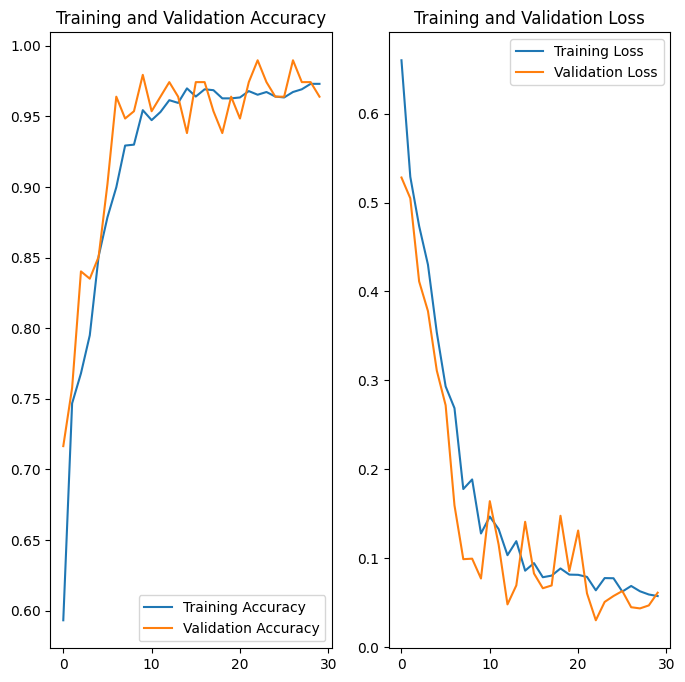

In [67]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [68]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


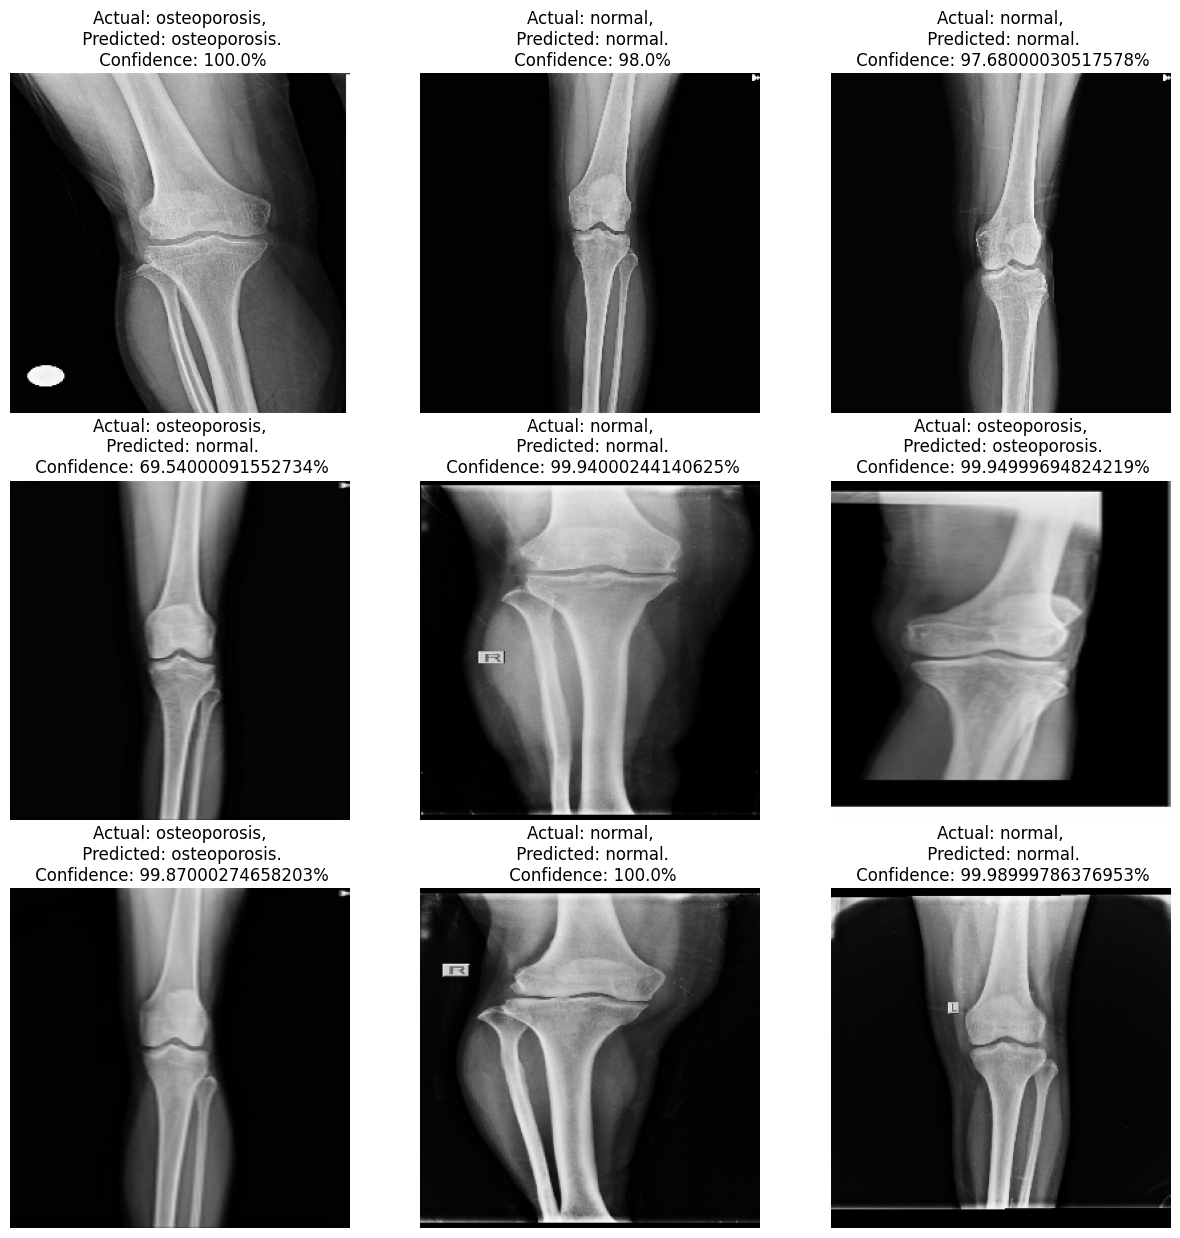

In [72]:
import numpy as np
class_names = ['normal', 'osteoporosis']
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

In [73]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Assuming val_ds returns (images, labels)
y_true = np.concatenate([labels for _, labels in val_ds])
y_pred = np.argmax(model.predict(val_ds), axis=1)

print(classification_report(y_true, y_pred))


9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step
              precision    recall  f1-score   support

           0       0.52      0.54      0.53       104
           1       0.44      0.42      0.43        90

    accuracy                           0.48       194
   macro avg       0.48      0.48      0.48       194
weighted avg       0.48      0.48      0.48       194



9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step
Confusion Matrix:
[[52 39]
 [50 53]]


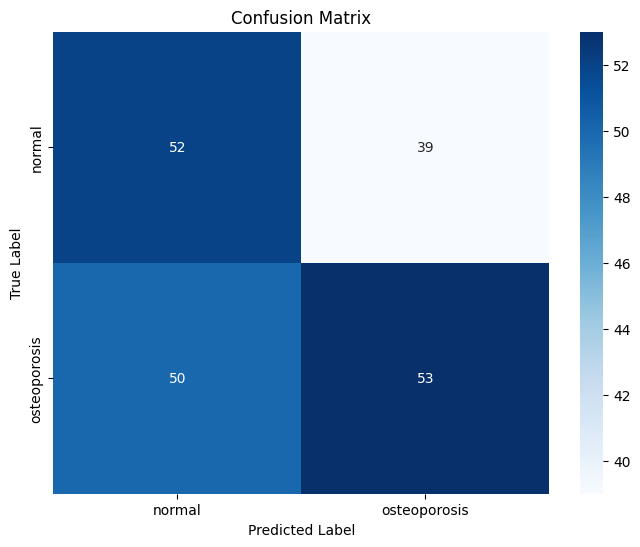

In [74]:
# prompt: print the confusion matrix for the model

import matplotlib.pyplot as plt
import numpy as np
# Generate predictions on the validation dataset
y_pred_val = np.argmax(model.predict(val_ds), axis=1)

# Get true labels from the validation dataset
y_true_val = np.concatenate([labels for _, labels in val_ds])

# Compute the confusion matrix
cm = confusion_matrix(y_true_val, y_pred_val)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Optional: Display the confusion matrix with labels (requires seaborn and matplotlib)
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()